In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [8]:
#2. Load Dataset
df = pd.read_csv("/content/sample_data/Google_Stock_Price.csv", thousands=',')

# Take Open column
data = df['Open'].values.reshape(-1, 1)

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
# Clean non-numeric values like 'GOOGL' / NaN from Open column, then scale
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)
data_scaled = scaler.fit_transform(data)

In [10]:
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [11]:
def create_dataset(dataset):
    X = []
    y = []

    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

In [12]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [13]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0805
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0021
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0011
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 9.8213e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 8.9245e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 7.6383e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.5966e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.3495e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4700e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/

In [15]:
predicted = model.predict(X_test)

predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


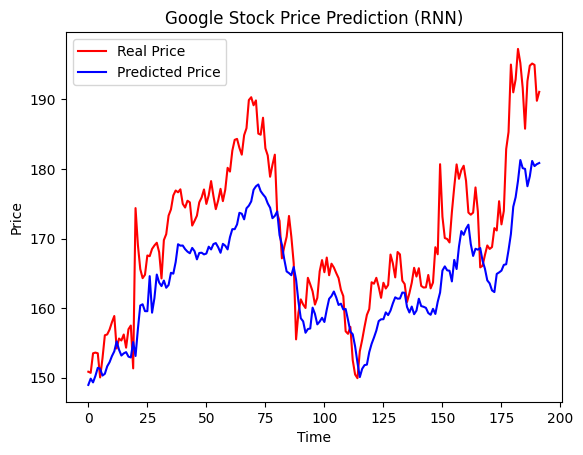

In [16]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()